#### CNN

#### 一、卷积层：寻找特征的放大镜
- 局部理解：卷积核每次只看一小块区域。在第一层，神经元直接接触像素，提取低级特征（对角线，垂直或水平边缘）
- 特征提取：当这些边缘特征进入中层，模型开始把它们拼接成更复杂的形状，到了深层，模型就能理解更抽象的概念，比如整张人脸或一只猫
- 特征图：卷积核滑过整张图后产生的结果叫特征图
。一个卷积层通常有几百个卷积核（比如 256 个），每个核都在寻找不同的特征，有的找颜色，有的找形状

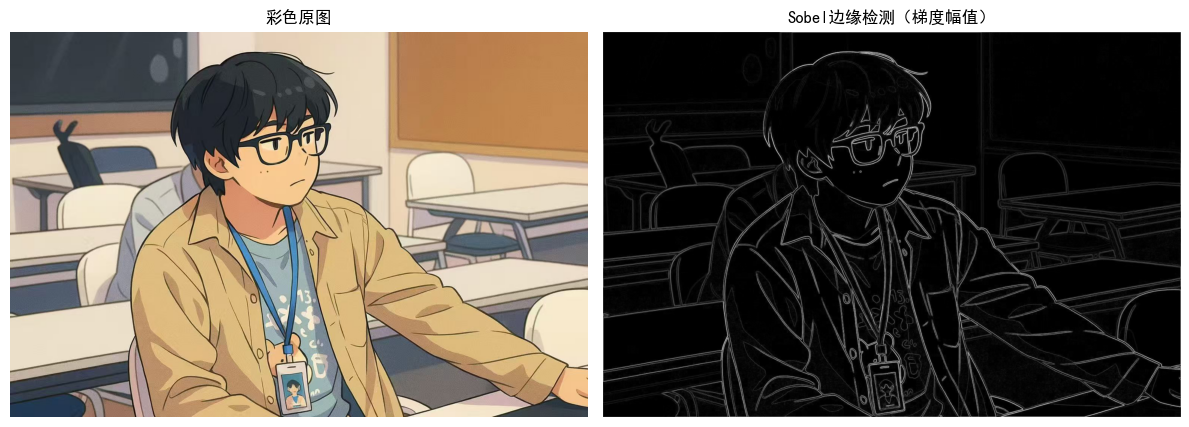

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
image_path = r"C:\Users\23017\Desktop\DL\Lecture 2 computer vision\image.jpg"  
img = Image.open(image_path).convert("RGB")          # 读取并转为RGB
transform = transforms.ToTensor()
img_tensor = transform(img).unsqueeze(0)             # [1, 3, H, W]，像素值范围[0,1]


# 垂直方向核（检测水平边缘）
sobel_v = torch.tensor([[[[-1., -2., -1.],
                          [ 0.,  0.,  0.],
                          [ 1.,  2.,  1.]]]], dtype=torch.float32)  # 形状[1,1,3,3]

# 水平方向核（检测垂直边缘）
sobel_h = torch.tensor([[[[-1., 0., 1.],
                          [-2., 0., 2.],
                          [-1., 0., 1.]]]], dtype=torch.float32)  # 形状[1,1,3,3]

# 将核复制到3个输入通道（RGB三个通道各自独立卷积，然后求和）
sobel_v_rgb = sobel_v.repeat(1, 3, 1, 1)   
sobel_h_rgb = sobel_h.repeat(1, 3, 1, 1)   


# 卷积核大小为3，填充为1，步长为1，输出通道为1，无偏置
conv_v = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1, bias=False)
conv_h = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1, bias=False)

with torch.no_grad():
    conv_v.weight = nn.Parameter(sobel_v_rgb)
    conv_h.weight = nn.Parameter(sobel_h_rgb)


with torch.no_grad():
    Gx = conv_h(img_tensor)   # 水平方向梯度（检测垂直边缘）
    Gy = conv_v(img_tensor)   # 垂直方向梯度（检测水平边缘）
    edge = torch.sqrt(Gx**2 + Gy**2)   # 梯度幅值（边缘强度）

# 转换为numpy并归一化到[0,1]用于显示
edge_np = edge.squeeze().cpu().numpy()
edge_np = (edge_np - edge_np.min()) / (edge_np.max() - edge_np.min() + 1e-8)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_tensor.squeeze().permute(1, 2, 0))
plt.title("彩色原图")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edge_np, cmap="gray")
plt.title("Sobel边缘检测（梯度幅值）")
plt.axis("off")

plt.tight_layout()
plt.show()

 #### 1.填充（Padding）：保护边缘    
 
在最基础的卷积中，图像没经过一次卷积就会缩水一圈。而且，边缘的像素只会被卷积核扫到一次，而中间的像素会被反复扫描，这会导致边缘信息逐渐丢失
- 填充就是在原始图像的四周补上一层（或几层）0。这就像是给照片加一个“零值相框”，让卷积核这个“滑动放大镜”能够越过原本的边界，确保边缘像素也能被充分提取
- 工程作用：最常用的是“Same Padding”，它的核心目的就是让输出特征图的大小和输入保持一致，这样我们才能搭建几十甚至上百层的深层网络

 #### 2.步幅（Stride）：卷积核的跳跃   

步幅决定卷积核在图像上的移动跨度  
- 直观理解：如果步幅为 1，卷积核就是一格一格地挪动；如果步幅为 2，它就会每次跳过一个像素
- 工程作用：步幅越大，输出的特征图就越小。在实际工程中，我们常利用大步幅卷积来替代传统的池化层（Pooling）进行下采样，以大幅减少计算量和内存占用

 #### 3.输入与输出通道：视觉深度
- 输入通道 (Input Channels)：最常见的就是彩色图片的 RGB 三通道。每一层卷积都会同时处理所有输入通道的信息
- 输出通道 (Output Channels)：它等于你使用的卷积核（Filter）的数量。比如，如果你在这一层用了 256 个卷积核，那么输出就会有 256 个通道
- 为什么需要多通道？：每个卷积核都在寻找不同的特征。有的核在找蓝色的边缘，有的在找圆形的轮廓，有的在找垂直的线条。通道越多，模型捕捉到的特征就越丰富

 #### 形状确定
假设输入大小为$N\times N$，卷积核大小为$F\times F$，填充为P，步幅为S。输出大小O为：
$$O = \frac{N + 2P - F}{S} + 1$$

#### 二、池化层：精简信息的“过滤器” 
在卷积之后，数据量依然庞大。池化层作用就是“压缩“
- 最大池化：这是最常用的方法。它在每个小窗口（比如 2x2）里只留下那个最强的信号（最大值），其他的都扔掉
- 依据：减少计算量，让训练更快。提供了”平移不变性“，如果猫的耳朵稍微动了几个像素，最大池化依然能捕捉到最强的那个信号，模型依然能认出它是耳朵
- 不可逆性：要注意，池化是不可逆的。一旦你只留下了最大值，你就不知道原本那个值是在窗口的哪个具体位置了。在高级的可视化研究中，我们会用“开关（Switches）”来记录位置，以便反向还原图像

#### 三、全连接层与输出
当图片经过层层卷积和池化后，特征已经被高度提炼。最后将特征平铺，送入全连接层：
- 最终决策：全连接层会综合所有局部特征（眼睛、耳朵、胡须），最后给出一个概率
- 架构痛点：全连接层虽然强大，但它会丢失空间信息。为了让模型更具可解释性，现代架构有时会使用全局平均池化（Global Average Pooling）来取代部分全连接层，这样我们可以直接追溯到模型到底是看了图像的哪个部位才做出的决定

#### 采用数据集为CIFAR10.该数据有10个类别,包含:  
airplane（飞机）  

automobile（汽车）  

bird（鸟）  

cat（猫）  

deer（鹿）  

dog（狗）  

frog（青蛙）  

horse（马）  

ship（船）  

truck（卡车）

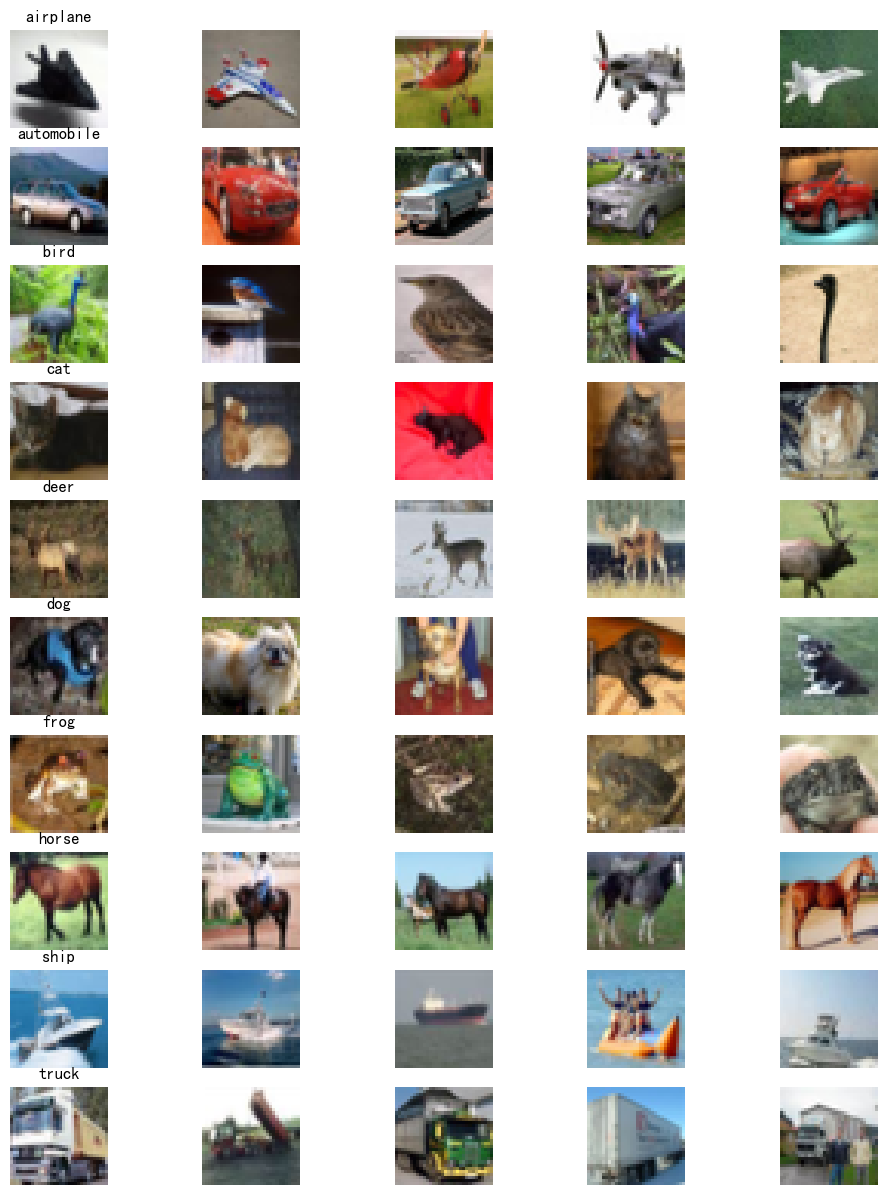

In [4]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
# 预处理
transform = transforms.ToTensor()
#若没有下载则
#train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
#test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainset = torchvision.datasets.CIFAR10(
    root=r'C:\Users\23017\Desktop\DL\data',
    train=True,
    download=False,   
    transform=transform
)

# 类别名
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# 每个类取 5 张图
class_images = {i: [] for i in range(10)}
for img, label in trainset:
    if len(class_images[label]) < 5:
        class_images[label].append(img)
    if all(len(imgs) == 5 for imgs in class_images.values()):
        break

# 画图
plt.figure(figsize=(12, 15))
for row in range(10):
    for col in range(5):
        plt.subplot(10, 5, row*5 + col + 1)
        img = class_images[row][col].permute(1,2,0).numpy()
        plt.imshow(img)
        plt.axis('off')
        if col == 0:
            plt.title(classes[row])
plt.show()

#### 首先完成一个二分类任务

In [5]:
#猫狗分类
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

使用设备: cuda


In [7]:
#加载数据
transform = transforms.Compose([transforms.ToTensor()])
train_set = datasets.CIFAR10(root=r'C:\Users\23017\Desktop\DL\data', train=True, download=False, transform=transform)
test_set = datasets.CIFAR10(root=r'C:\Users\23017\Desktop\DL\data', train=False, download=False, transform=transform)
# CIFAR10 标签：3=猫，5=狗
def filter_cat_dog(dataset):
    data = []
    labels = []
    for img, y in dataset:
        if y == 3:
            data.append(img.numpy())
            labels.append(0)    # 猫 = 0
        elif y == 5:
            data.append(img.numpy())
            labels.append(1)    # 狗 = 1
    return torch.tensor(np.array(data)), torch.tensor(np.array(labels)).long()

In [8]:
# 过滤出猫和狗
x_train, y_train = filter_cat_dog(train_set)
x_test, y_test = filter_cat_dog(test_set)
# 构建加载器
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=64, shuffle=False)

In [9]:
#搭建CNN
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3,32,3,padding =1) #输入通道数，输出通道数，卷积核大小,填充
    self.conv2 = nn.Conv2d(32,64,3,padding =1) #输入通道数，输出通道数，卷积核大小,填充
    self.conv3 = nn.Conv2d(64,128,3,padding =1) #输入通道数，输出通道数，卷积核大小,填充
    self.pool = nn.MaxPool2d(2,2) #池化层
    self.fc1 = nn.Linear(128*4*4,128) #全连接层
    self.fc2 = nn.Linear(128,2) #全连接层,输出分类(猫或狗)
    self.relu = nn.ReLU()
    
  def forward(self, x):
      x = self.pool(self.relu(self.conv1(x)))
      x = self.pool(self.relu(self.conv2(x)))
      x = self.pool(self.relu(self.conv3(x)))
      x = x.view(-1, 128 * 4 * 4)
      x = self.relu(self.fc1(x))
      x = self.fc2(x)
      return x

model = CNN().to(device)

In [10]:
#损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:

epochs = 20
train_acc_list = []
test_acc_list = []
train_loss_list = []  
test_loss_list = []   

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0
    total_loss = 0.0

    # 训练
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_acc = correct / total
    train_loss = total_loss / len(train_loader)
    
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)  # 保存训练损失

    # 测试
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = correct / total
    test_loss = total_loss / len(test_loader)
    
    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)  # 保存测试损失

    print(f"[{epoch+1}/{epochs}] 训练Loss: {train_loss:.3f} | 测试Loss: {test_loss:.3f} | 训练Acc: {train_acc:.2f} | 测试Acc: {test_acc:.2f}")

[1/20] 训练Loss: 0.659 | 测试Loss: 0.614 | 训练Acc: 0.60 | 测试Acc: 0.67
[2/20] 训练Loss: 0.596 | 测试Loss: 0.573 | 训练Acc: 0.68 | 测试Acc: 0.70
[3/20] 训练Loss: 0.542 | 测试Loss: 0.512 | 训练Acc: 0.72 | 测试Acc: 0.74
[4/20] 训练Loss: 0.499 | 测试Loss: 0.516 | 训练Acc: 0.76 | 测试Acc: 0.74
[5/20] 训练Loss: 0.465 | 测试Loss: 0.467 | 训练Acc: 0.78 | 测试Acc: 0.77
[6/20] 训练Loss: 0.427 | 测试Loss: 0.484 | 训练Acc: 0.80 | 测试Acc: 0.76
[7/20] 训练Loss: 0.401 | 测试Loss: 0.451 | 训练Acc: 0.81 | 测试Acc: 0.77
[8/20] 训练Loss: 0.361 | 测试Loss: 0.484 | 训练Acc: 0.84 | 测试Acc: 0.76
[9/20] 训练Loss: 0.318 | 测试Loss: 0.493 | 训练Acc: 0.86 | 测试Acc: 0.78
[10/20] 训练Loss: 0.291 | 测试Loss: 0.487 | 训练Acc: 0.87 | 测试Acc: 0.79
[11/20] 训练Loss: 0.242 | 测试Loss: 0.592 | 训练Acc: 0.90 | 测试Acc: 0.77
[12/20] 训练Loss: 0.193 | 测试Loss: 0.563 | 训练Acc: 0.92 | 测试Acc: 0.79
[13/20] 训练Loss: 0.161 | 测试Loss: 0.614 | 训练Acc: 0.94 | 测试Acc: 0.78
[14/20] 训练Loss: 0.127 | 测试Loss: 0.687 | 训练Acc: 0.95 | 测试Acc: 0.79
[15/20] 训练Loss: 0.090 | 测试Loss: 0.791 | 训练Acc: 0.97 | 测试Acc: 0.77
[16/20] 训练Loss: 0.0

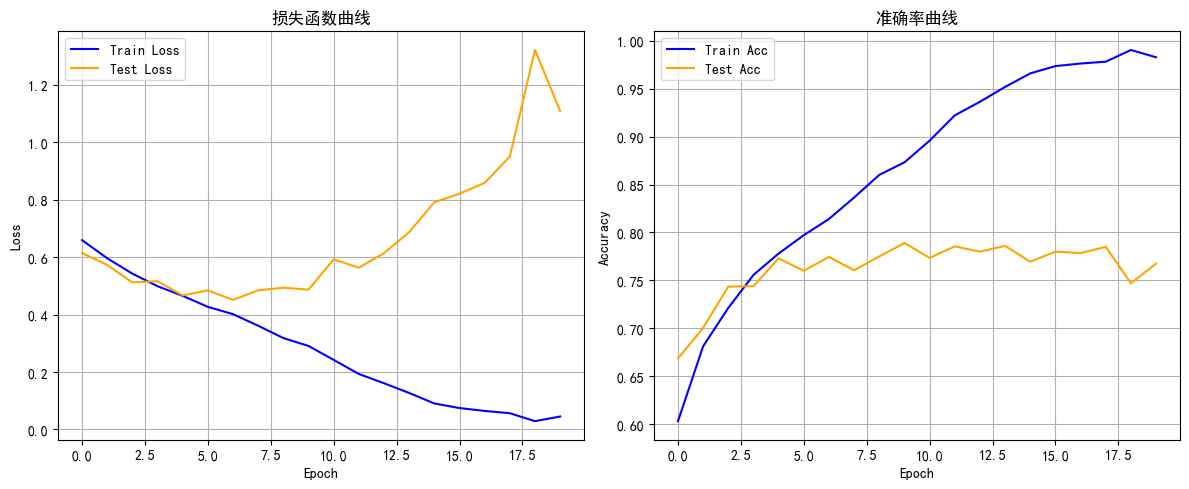

In [12]:
plt.figure(figsize=(12, 5))  

# 损失函数
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss', color='blue')
plt.plot(test_loss_list, label='Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('损失函数曲线')
plt.legend()
plt.grid(True)
# 准确率
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc', color='blue')
plt.plot(test_acc_list, label='Test Acc', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('准确率曲线')
plt.legend()
plt.grid(True)
plt.tight_layout()  
plt.show()

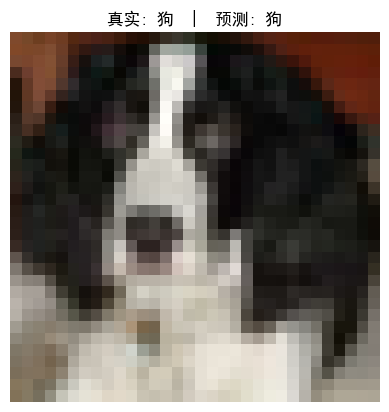

In [13]:
#预测
def predict(img):
    model.eval()
    img = img.unsqueeze(0).to(device)
    output = model(img)
    return "狗" if torch.argmax(output).item() else "猫"

# 随机显示一张图
idx = 42
img = x_test[idx]
true_label = "猫" if y_test[idx] == 0 else "狗"
pred_label = predict(img)

plt.imshow(img.permute(1,2,0))
plt.title(f"真实: {true_label}  |  预测: {pred_label}")
plt.axis('off')
plt.show()

#### 接下来,我们进行多分类

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

transform = transforms.ToTensor()


train_set = datasets.CIFAR10(root=r'C:\Users\23017\Desktop\DL\data', train=True, download=False, transform=transform)
test_set = datasets.CIFAR10(root=r'C:\Users\23017\Desktop\DL\data', train=False, download=False, transform=transform)

# DataLoader
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

# CIFAR10 类别
classes = ['飞机', '汽车', '鸟', '猫', '鹿',
           '狗', '青蛙', '马', '船', '卡车']

使用设备: cuda


In [16]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
epochs = 20
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(epochs):
    # 训练
    model.train()
    correct, total = 0, 0
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)

    # 测试
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = correct / total
    test_loss = total_loss / len(test_loader)
    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)

    print(f"[{epoch+1}/{epochs}] "
          f"训练Loss: {train_loss:.3f} | 测试Loss: {test_loss:.3f} | "
          f"训练Acc: {train_acc:.2f} | 测试Acc: {test_acc:.2f}")


[1/20] 训练Loss: 1.586 | 测试Loss: 1.320 | 训练Acc: 0.42 | 测试Acc: 0.53
[2/20] 训练Loss: 1.180 | 测试Loss: 1.069 | 训练Acc: 0.58 | 测试Acc: 0.62
[3/20] 训练Loss: 1.006 | 测试Loss: 1.023 | 训练Acc: 0.64 | 测试Acc: 0.63
[4/20] 训练Loss: 0.892 | 测试Loss: 0.957 | 训练Acc: 0.69 | 测试Acc: 0.67
[5/20] 训练Loss: 0.809 | 测试Loss: 0.897 | 训练Acc: 0.72 | 测试Acc: 0.69
[6/20] 训练Loss: 0.729 | 测试Loss: 0.835 | 训练Acc: 0.75 | 测试Acc: 0.71
[7/20] 训练Loss: 0.670 | 测试Loss: 0.861 | 训练Acc: 0.77 | 测试Acc: 0.71
[8/20] 训练Loss: 0.614 | 测试Loss: 0.870 | 训练Acc: 0.78 | 测试Acc: 0.70
[9/20] 训练Loss: 0.564 | 测试Loss: 0.873 | 训练Acc: 0.80 | 测试Acc: 0.71
[10/20] 训练Loss: 0.516 | 测试Loss: 0.867 | 训练Acc: 0.82 | 测试Acc: 0.72
[11/20] 训练Loss: 0.470 | 测试Loss: 0.902 | 训练Acc: 0.83 | 测试Acc: 0.72
[12/20] 训练Loss: 0.427 | 测试Loss: 0.932 | 训练Acc: 0.85 | 测试Acc: 0.71
[13/20] 训练Loss: 0.394 | 测试Loss: 0.912 | 训练Acc: 0.86 | 测试Acc: 0.72
[14/20] 训练Loss: 0.357 | 测试Loss: 0.996 | 训练Acc: 0.87 | 测试Acc: 0.72
[15/20] 训练Loss: 0.321 | 测试Loss: 1.060 | 训练Acc: 0.88 | 测试Acc: 0.72
[16/20] 训练Loss: 0.2

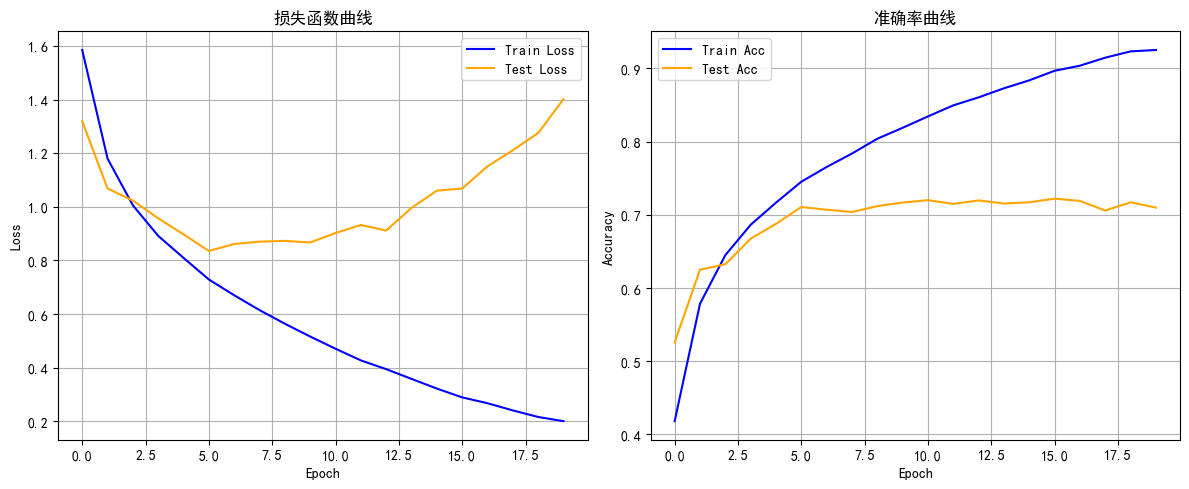

In [19]:
plt.figure(figsize=(12, 5))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss', color='blue')
plt.plot(test_loss_list, label='Test Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('损失函数曲线')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Train Acc', color='blue')
plt.plot(test_acc_list, label='Test Acc', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('准确率曲线')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### 过拟合
- 训练损失：一路下降，越来越低（甚至接近 0）
- 测试损失：降到最低点后，开始反弹、上升！
- 两条线 开始分叉、越来越远

#### 欠拟合
- 训练损失和测试损失都 很高，降不下去
- 两条线 贴在一起，但都很高


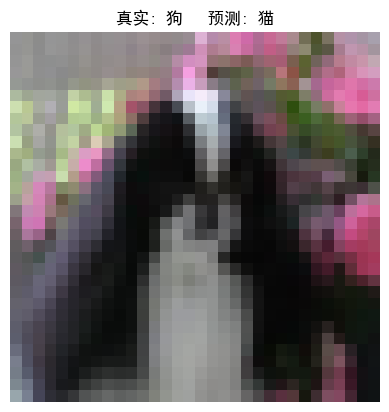

In [20]:
#预测
def predict(img):
    model.eval()
    img = img.unsqueeze(0).to(device)
    output = model(img)
    return classes[torch.argmax(output).item()]

# 随机测试一张
idx = 42
img, label = test_set[idx]
pred = predict(img)
true = classes[label]

plt.imshow(img.permute(1, 2, 0))
plt.title(f"真实: {true}   预测: {pred}")
plt.axis('off')
plt.show()

#### 最后多分类任务出现过拟合.且最后预测的结果也是错的,下个Lecture会介绍如何提供准确率,并防止过拟合

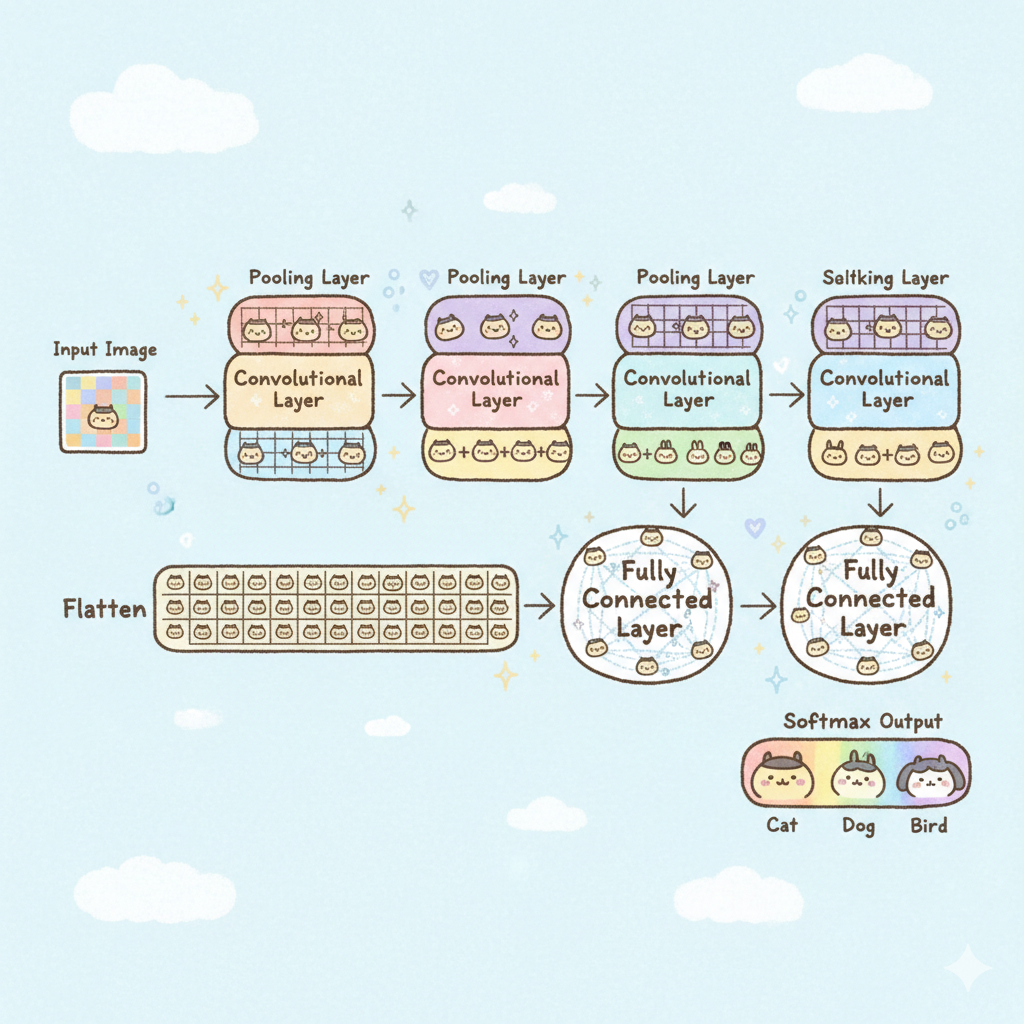